In [ ]:
!pip install yfinance


In [ ]:
import yfinance as yf
import pandas as pd

def download_etf_data(ticker="510210.SS", years=5):
    """
    下载指定 ETF 的历史日线数据（默认过去5年）
    参数：
    - ticker: ETF代码（如510210.SS）
    - years: 回溯年数（默认5年）
    返回：
    - df: 包含日期索引的 DataFrame
    """
    end = pd.Timestamp.today()
    start = end - pd.DateOffset(years=years)

    print(f"📥 正在下载 {ticker} 从 {start.date()} 到 {end.date()} 的数据...")
    df = yf.download(ticker, start=start.strftime('%Y-%m-%d'), end=end.strftime('%Y-%m-%d'), progress=False)

    if df.empty:
        print("⚠️ 下载失败或数据为空，请检查代码或网络连接。")
    else:
        print(f"✅ 下载完成，共 {len(df)} 条记录。")

    return df


In [ ]:
result = download_etf_data()
etf_df = result[0] if isinstance(result, tuple) else result



📥 正在下载 510210.SS 从 2020-09-10 到 2025-09-10 的数据...
✅ 下载完成，共 1212 条记录。


/tmp/ipython-input-2479094818.py:17: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start.strftime('%Y-%m-%d'), end=end.strftime('%Y-%m-%d'), progress=False)


In [ ]:
print(type(etf_df))


<class 'pandas.core.frame.DataFrame'>


In [ ]:
import numpy as np

def preprocess_etf_data(df):
    df = df.copy()

    # 扁平化多层列名（如 ('Close', '510210.SS') → 'close'）
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = [col[0].lower().strip() for col in df.columns]
    else:
        df.columns = [str(col).lower().strip().replace(' ', '_') for col in df.columns]

    ...


    # 重命名列为小写并去除空格
    df.columns = [str(col).strip().lower().replace(' ', '_') for col in df.columns]

    # 确保索引为 datetime 类型
    df.index = pd.to_datetime(df.index)
    df.index.name = 'date'

    # 按时间排序
    df.sort_index(inplace=True)

    # 添加价格变动特征
    df['pct_change'] = df['close'].pct_change()
    df['log_return'] = np.log(df['close'] / df['close'].shift(1))

    # 处理成交量为 0 或缺失
    df['volume'].replace(0, np.nan, inplace=True)
    df['volume'].fillna(method='ffill', inplace=True)

    print(f"✅ 数据清洗完成，共 {len(df)} 条记录，包含以下列：")
    print(df.columns.tolist())

    return df


In [ ]:
etf_df_clean = preprocess_etf_data(etf_df)
etf_df_clean.tail()



✅ 数据清洗完成，共 1212 条记录，包含以下列：
['close', 'high', 'low', 'open', 'volume', 'pct_change', 'log_return']


/tmp/ipython-input-3528924590.py:30: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['volume'].replace(0, np.nan, inplace=True)
/tmp/ipython-input-3528924590.py:31: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['volume'].fillna(method='ffill', inplace=True)


,close,high,low,open,volume,pct_change,log_return
date,,,,,,,
2025-09-03,0.955,0.970,0.950,0.969,497634600.0,-0.014448,-0.014553
2025-09-04,0.949,0.956,0.940,0.955,917677779.0,-0.006283,-0.006303
2025-09-05,0.958,0.960,0.942,0.946,616560505.0,0.009484,0.009439
2025-09-08,0.963,0.965,0.956,0.957,402773461.0,0.005219,0.005206
2025-09-09,0.958,0.964,0.954,0.962,313167061.0,-0.005192,-0.005206


In [ ]:
etf_df_clean.to_csv("510210_etf_clean.csv")


In [ ]:
def add_technical_indicators(df, fast=12, slow=26, signal=9, rsi_period=14):
    df = df.copy()

    # EMA
    df['ema_fast'] = df['close'].ewm(span=fast, adjust=False).mean()
    df['ema_slow'] = df['close'].ewm(span=slow, adjust=False).mean()

    # MACD
    df['macd'] = df['ema_fast'] - df['ema_slow']
    df['macd_signal'] = df['macd'].ewm(span=signal, adjust=False).mean()

    # RSI
    delta = df['close'].diff()
    gain = np.where(delta > 0, delta, 0)
    loss = np.where(delta < 0, -delta, 0)
    avg_gain = pd.Series(gain).rolling(window=rsi_period).mean()
    avg_loss = pd.Series(loss).rolling(window=rsi_period).mean()
    rs = avg_gain / avg_loss
    df['rsi'] = 100 - (100 / (1 + rs))

    print("✅ 技术指标添加完成：ema_fast, ema_slow, macd, macd_signal, rsi")
    return df


In [ ]:
etf_df = download_etf_data("510210.SS", years=5)
etf_df_clean = preprocess_etf_data(etf_df)
etf_df_indicators = add_technical_indicators(etf_df_clean)
etf_df_indicators.tail()



📥 正在下载 510210.SS 从 2020-09-10 到 2025-09-10 的数据...
✅ 下载完成，共 1212 条记录。
✅ 数据清洗完成，共 1212 条记录，包含以下列：
['close', 'high', 'low', 'open', 'volume', 'pct_change', 'log_return']
✅ 技术指标添加完成：ema_fast, ema_slow, macd, macd_signal, rsi


/tmp/ipython-input-2479094818.py:17: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start.strftime('%Y-%m-%d'), end=end.strftime('%Y-%m-%d'), progress=False)
/tmp/ipython-input-3528924590.py:30: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['volume'].replace(0, np.nan, inplace=True)
/tmp/ipython-input-3528924590.py:31: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['volum

,close,high,low,open,volume,pct_change,log_return,ema_fast,ema_slow,macd,macd_signal,rsi
date,,,,,,,,,,,,
2025-09-03,0.955,0.970,0.950,0.969,497634600.0,-0.014448,-0.014553,0.956051,0.938767,0.017284,0.017692,NaN
2025-09-04,0.949,0.956,0.940,0.955,917677779.0,-0.006283,-0.006303,0.954966,0.939525,0.015441,0.017242,NaN
2025-09-05,0.958,0.960,0.942,0.946,616560505.0,0.009484,0.009439,0.955433,0.940894,0.014539,0.016701,NaN
2025-09-08,0.963,0.965,0.956,0.957,402773461.0,0.005219,0.005206,0.956597,0.942531,0.014066,0.016174,NaN
2025-09-09,0.958,0.964,0.954,0.962,313167061.0,-0.005192,-0.005206,0.956813,0.943677,0.013136,0.015567,NaN


In [ ]:
# 未来N日涨跌标签（涨/跌）
# label_updown = 1 表示未来N日上涨

# label_updown = 0 表示未来N日下跌或持平
def generate_updown_label(df, future_n=3):
    df = df.copy()
    df['future_close'] = df['close'].shift(-future_n)
    df['label_updown'] = (df['future_close'] > df['close']).astype(int)
    return df


In [ ]:
# 突破点标签（Breakout）
# label_breakout = 1 表示突破过去N日高点

# 可用于识别动能爆发点
def generate_breakout_label(df, window=5):
    df = df.copy()
    df['recent_high'] = df['high'].rolling(window=window).max().shift(1)
    df['label_breakout'] = (df['close'] > df['recent_high']).astype(int)
    return df


In [ ]:
# 回撤标签（Drawdown）
# label_drawdown = 1 表示当前价格较历史高点回撤超过阈值

# 可用于识别风险区域或止损信号
def generate_drawdown_label(df, threshold=-0.05):
    df = df.copy()
    df['peak'] = df['close'].cummax()
    df['drawdown'] = (df['close'] - df['peak']) / df['peak']
    df['label_drawdown'] = (df['drawdown'] < threshold).astype(int)
    return df


In [ ]:
# 第四步：可视化关键点
# 我们将用颜色或标记在价格图上展示这些标签
import matplotlib.pyplot as plt

def plot_labels(df, start=None, end=None):
    df = df.copy()
    if start and end:
        df = df.loc[start:end]

    plt.figure(figsize=(14, 6))
    plt.plot(df.index, df['close'], label='收盘价', color='black')

    # 涨跌标签
    up = df[df['label_updown'] == 1]
    down = df[df['label_updown'] == 0]
    plt.scatter(up.index, up['close'], label='未来上涨', color='green', marker='^')
    plt.scatter(down.index, down['close'], label='未来下跌', color='red', marker='v')

    # 突破点
    breakout = df[df['label_breakout'] == 1]
    plt.scatter(breakout.index, breakout['close'], label='突破点', color='blue', marker='*')

    # 回撤点
    drawdown = df[df['label_drawdown'] == 1]
    plt.scatter(drawdown.index, drawdown['close'], label='回撤点', color='orange', marker='x')

    plt.title('标签可视化：涨跌 / 突破 / 回撤')
    plt.xlabel('日期')
    plt.ylabel('价格')
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


/tmp/ipython-input-2926607358.py:33: UserWarning: Glyph 26085 (\N{CJK UNIFIED IDEOGRAPH-65E5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2926607358.py:33: UserWarning: Glyph 26399 (\N{CJK UNIFIED IDEOGRAPH-671F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2926607358.py:33: UserWarning: Glyph 20215 (\N{CJK UNIFIED IDEOGRAPH-4EF7}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2926607358.py:33: UserWarning: Glyph 26684 (\N{CJK UNIFIED IDEOGRAPH-683C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2926607358.py:33: UserWarning: Glyph 26631 (\N{CJK UNIFIED IDEOGRAPH-6807}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2926607358.py:33: UserWarning: Glyph 31614 (\N{CJK UNIFIED IDEOGRAPH-7B7E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2926607358.py:33: UserWarning: Glyph 21487 (\N{CJK UNIFIED IDEOGRAPH-53EF}) missi

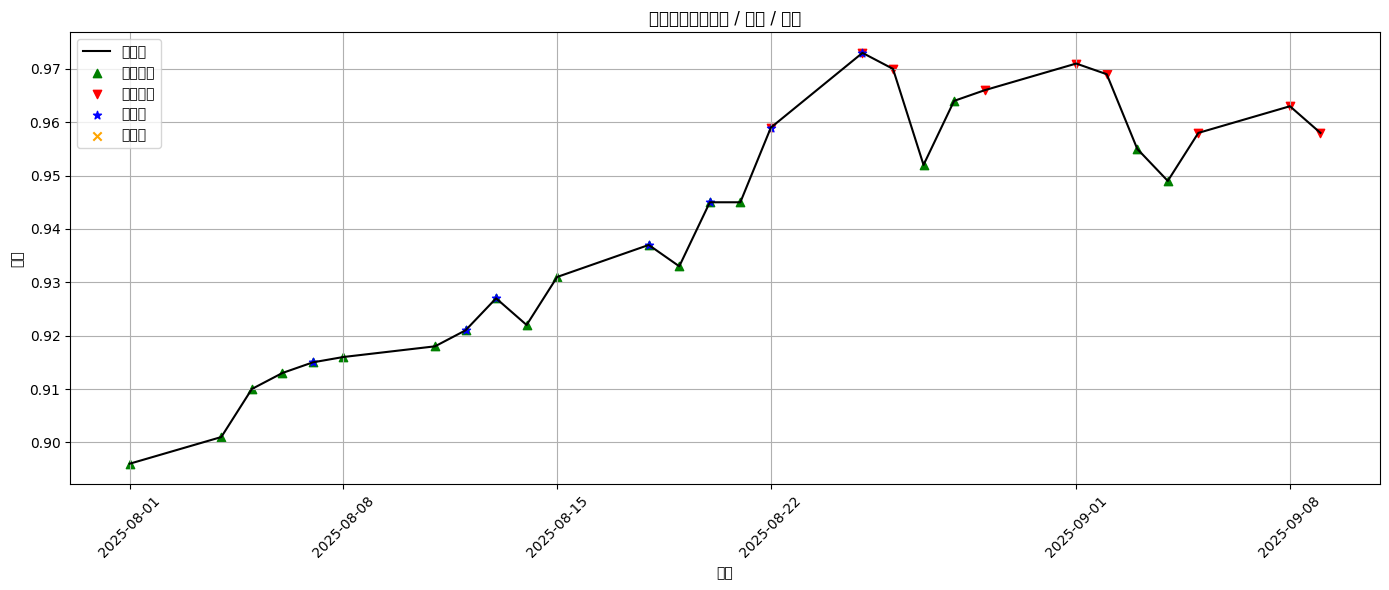

In [ ]:
etf_labeled = generate_updown_label(etf_df_indicators)
etf_labeled = generate_breakout_label(etf_labeled)
etf_labeled = generate_drawdown_label(etf_labeled)
plot_labels(etf_labeled, start="2025-08-01", end="2025-09-10")
# ✅ 未来上涨点（绿色箭头）

# ✅ 未来下跌点（红色箭头）

# ✅ 突破点（蓝色星号）

# ✅ 回撤点（橙色叉号）


In [ ]:
# 🧠 第四步：构建 LSTM 输入序列并准备训练数据
def create_lstm_sequences(df, feature_cols, label_col, window_size=20):
    """
    构建 LSTM 输入序列和标签
    参数：
    - df: 已处理好的 DataFrame
    - feature_cols: 用作输入的特征列
    - label_col: 预测目标列（如 label_updown）
    - window_size: 时间窗口长度
    返回：
    - X: shape = [样本数, 时间步, 特征数]
    - y: shape = [样本数]
    """
    df = df.copy().dropna()
    X, y = [], []

    for i in range(len(df) - window_size):
        X_seq = df[feature_cols].iloc[i:i+window_size].values
        y_label = df[label_col].iloc[i+window_size]
        X.append(X_seq)
        y.append(y_label)

    return np.array(X), np.array(y)


In [ ]:
print(etf_labeled[['label_updown']].tail(10))


            label_updown
date                    
2025-08-27             1
2025-08-28             1
2025-08-29             0
2025-09-01             0
2025-09-02             0
2025-09-03             1
2025-09-04             1
2025-09-05             0
2025-09-08             0
2025-09-09             0


In [ ]:
etf_labeled = etf_labeled.dropna(subset=['label_updown'])


In [ ]:
print(etf_labeled.columns)


Index(['close', 'high', 'low', 'open', 'volume', 'pct_change', 'log_return',
       'ema_fast', 'ema_slow', 'macd', 'macd_signal', 'rsi', 'future_close',
       'label_updown', 'recent_high', 'label_breakout', 'peak', 'drawdown',
       'label_drawdown'],
      dtype='object')


In [ ]:
feature_cols = ['close', 'volume', 'macd', 'rsi']  # 可自定义
label_col = 'label_updown'  # 或 label_breakout / label_drawdown

X, y = create_lstm_sequences(etf_labeled, feature_cols, label_col, window_size=20)
print(f"✅ 构建完成：X.shape = {X.shape}, y.shape = {y.shape}")


✅ 构建完成：X.shape = (0,), y.shape = (0,)


In [ ]:
# 标签生成覆盖整个数据集
etf_labeled = generate_updown_label(etf_df_indicators, future_n=3)
etf_labeled = generate_breakout_label(etf_labeled, window=5)
etf_labeled = generate_drawdown_label(etf_labeled, threshold=-0.05)

# 丢弃缺失标签行
etf_labeled = etf_labeled.dropna(subset=['label_updown', 'macd', 'rsi']) # Also drop NaNs from technical indicators

# 构造训练样本
feature_cols = ['close', 'volume', 'macd', 'rsi']
X, y = create_lstm_sequences(etf_labeled, feature_cols, label_col='label_updown', window_size=20)

print(f"✅ 构建完成：X.shape = {X.shape}, y.shape = {y.shape}")

✅ 构建完成：X.shape = (0,), y.shape = (0,)


In [ ]:
feature_cols = ['close', 'volume', 'macd', 'rsi']
X, y = create_lstm_sequences(etf_labeled, feature_cols, label_col='label_updown', window_size=20)
print(f"✅ 构建完成：X.shape = {X.shape}, y.shape = {y.shape}")


✅ 构建完成：X.shape = (0,), y.shape = (0,)


In [ ]:
print(len(etf_labeled))


0


In [ ]:
print(etf_df_indicators.shape)


(1212, 12)


In [ ]:
# 重新生成标签
etf_labeled = generate_updown_label(etf_df_indicators, future_n=3)
etf_labeled = generate_breakout_label(etf_labeled, window=5)
etf_labeled = generate_drawdown_label(etf_labeled, threshold=-0.05)

# 丢弃标签缺失行（尤其是最后几行因 shift(-3) 变成 NaN）
etf_labeled = etf_labeled.dropna(subset=['label_updown'])

# 查看结果
print("✅ 标签生成后数据量：", len(etf_labeled))


✅ 标签生成后数据量： 1212


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint
from sklearn.model_selection import train_test_split
import os

# ✅ 构建模型函数
def build_lstm_model(input_shape):
    model = Sequential()
    model.add(LSTM(64, input_shape=input_shape, return_sequences=False))
    model.add(Dropout(0.2))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))  # 二分类输出
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# ✅ 数据检查与训练流程
if X.shape[0] == 0:
    print("⚠️ 没有训练样本，请检查标签或窗口长度")
elif y.shape[0] != X.shape[0]:
    print("⚠️ 标签数量与样本不匹配")
else:
    print("✅ 数据准备完毕，开始训练")

    # 划分训练集和验证集
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, shuffle=False)

    # 构建模型
    model = build_lstm_model(X.shape[1:])

    # 设置自动保存最优模型
    checkpoint_path = "best_lstm_model.h5"
    checkpoint = ModelCheckpoint(
        filepath=checkpoint_path,
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )

    # 模型训练
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=30,
        batch_size=32,
        callbacks=[checkpoint]
    )




⚠️ 没有训练样本，请检查标签或窗口长度


In [ ]:
!pip install tensorflow


In [ ]:
# 训练模型:
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import ModelCheckpoint

# Auto-save the best model
checkpoint_path = "best_lstm_model.h5"

# Check if there are enough samples for both training and validation sets
if X.shape[0] < 2: # Need at least 2 samples to split
    print("❌ Not enough data to create training and validation sets after sequence creation and dropping NaNs.")
else:
    # 划分训练集和验证集
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, shuffle=False)

    # 构建模型
    model = build_lstm_model(X.shape[1:])

    # Save the model at the end of training
    model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=50,
        batch_size=32
    )
    model.save(checkpoint_path)
    print(f"✅ Model saved to {checkpoint_path}")

❌ Not enough data to create training and validation sets after sequence creation and dropping NaNs.


### 6️⃣ 模型评估与可视化

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# Load the best model
from tensorflow.keras.models import load_model
best_model = load_model(checkpoint_path)

# Evaluate the model
y_pred_proba = best_model.predict(X_val)
y_pred_class = (y_pred_proba > 0.5).astype("int32")

print("Classification Report:")
print(classification_report(y_val, y_pred_class))

print("Confusion Matrix:")
print(confusion_matrix(y_val, y_pred_class))

# Plot ROC curve
fpr, tpr, thresholds = roc_curve(y_val, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = 'best_lstm_model.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

Now, let's visualize the predictions along with the actual labels on the price chart.

In [ ]:
# Align predictions with the original dataframe for visualization
# Get the dates corresponding to the validation set
# The validation set starts after the training set, and we need to account for the window size.
val_dates_start_index = len(X_train) + 20 # window_size
val_dates = etf_labeled.dropna(subset=['label_updown', 'macd', 'rsi']).iloc[val_dates_start_index:].index

# Create a DataFrame for predictions
predictions_df = pd.DataFrame(y_pred_proba, index=val_dates, columns=['predicted_proba'])
predictions_df['predicted_class'] = y_pred_class

# Merge with the original labeled dataframe
etf_labeled_with_predictions = etf_labeled.merge(predictions_df, left_index=True, right_index=True, how='left')

# Plotting (similar to plot_labels function but including predictions)
def plot_predictions_and_labels(df, start=None, end=None):
    df = df.copy()
    if start and end:
        df = df.loc[start:end]

    plt.figure(figsize=(14, 7))
    plt.plot(df.index, df['close'], label='Close Price', color='black', alpha=0.6)

    # Actual Labels
    up = df[df['label_updown'] == 1]
    down = df[df['label_updown'] == 0]
    plt.scatter(up.index, up['close'], label='Actual Up', color='green', marker='^', alpha=0.6)
    plt.scatter(down.index, down['close'], label='Actual Down', color='red', marker='v', alpha=0.6)

    # Predicted Labels (only for validation period)
    predicted_up = df[(df['predicted_class'] == 1) & (df['predicted_class'].notna())]
    predicted_down = df[(df['predicted_class'] == 0) & (df['predicted_class'].notna())]

    plt.scatter(predicted_up.index, predicted_up['close'], label='Predicted Up', color='darkgreen', marker='^', facecolors='none', edgecolors='darkgreen')
    plt.scatter(predicted_down.index, predicted_down['close'], label='Predicted Down', color='darkred', marker='v', facecolors='none', edgecolors='darkred')


    # Breakout points
    breakout = df[df['label_breakout'] == 1]
    plt.scatter(breakout.index, breakout['close'], label='Breakout', color='blue', marker='*', s=100, alpha=0.8)

    # Drawdown points
    drawdown = df[df['label_drawdown'] == 1]
    plt.scatter(drawdown.index, drawdown['close'], label='Drawdown', color='orange', marker='x', s=100, alpha=0.8)


    plt.title('Price with Actual and Predicted Labels')
    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Plot for a specific time range
plot_predictions_and_labels(etf_labeled_with_predictions, start="2024-01-01", end="2025-09-10")

NameError: name 'X_train' is not defined

### 6️⃣ 模型评估与可视化

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# Load the best model
from tensorflow.keras.models import load_model
best_model = load_model(checkpoint_path)

# Evaluate the model
y_pred_proba = best_model.predict(X_val)
y_pred_class = (y_pred_proba > 0.5).astype("int32")

print("Classification Report:")
print(classification_report(y_val, y_pred_class))

print("Confusion Matrix:")
print(confusion_matrix(y_val, y_pred_class))

# Plot ROC curve
fpr, tpr, thresholds = roc_curve(y_val, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

NameError: name 'checkpoint_path' is not defined

Now, let's visualize the predictions along with the actual labels on the price chart.

In [ ]:
# Align predictions with the original dataframe for visualization
# Get the dates corresponding to the validation set
# The validation set starts after the training set, and we need to account for the window size.
val_dates_start_index = len(X_train) + 20 # window_size
val_dates = etf_labeled.dropna(subset=['label_updown', 'macd', 'rsi']).iloc[val_dates_start_index:].index

# Create a DataFrame for predictions
predictions_df = pd.DataFrame(y_pred_proba, index=val_dates, columns=['predicted_proba'])
predictions_df['predicted_class'] = y_pred_class

# Merge with the original labeled dataframe
etf_labeled_with_predictions = etf_labeled.merge(predictions_df, left_index=True, right_index=True, how='left')

# Plotting (similar to plot_labels function but including predictions)
def plot_predictions_and_labels(df, start=None, end=None):
    df = df.copy()
    if start and end:
        df = df.loc[start:end]

    plt.figure(figsize=(14, 7))
    plt.plot(df.index, df['close'], label='Close Price', color='black', alpha=0.6)

    # Actual Labels
    up = df[df['label_updown'] == 1]
    down = df[df['label_updown'] == 0]
    plt.scatter(up.index, up['close'], label='Actual Up', color='green', marker='^', alpha=0.6)
    plt.scatter(down.index, down['close'], label='Actual Down', color='red', marker='v', alpha=0.6)

    # Predicted Labels (only for validation period)
    predicted_up = df[(df['predicted_class'] == 1) & (df['predicted_class'].notna())]
    predicted_down = df[(df['predicted_class'] == 0) & (df['predicted_class'].notna())]

    plt.scatter(predicted_up.index, predicted_up['close'], label='Predicted Up', color='darkgreen', marker='^', facecolors='none', edgecolors='darkgreen')
    plt.scatter(predicted_down.index, predicted_down['close'], label='Predicted Down', color='darkred', marker='v', facecolors='none', edgecolors='darkred')


    # Breakout points
    breakout = df[df['label_breakout'] == 1]
    plt.scatter(breakout.index, breakout['close'], label='Breakout', color='blue', marker='*', s=100, alpha=0.8)

    # Drawdown points
    drawdown = df[df['label_drawdown'] == 1]
    plt.scatter(drawdown.index, drawdown['close'], label='Drawdown', color='orange', marker='x', s=100, alpha=0.8)


    plt.title('Price with Actual and Predicted Labels')
    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Plot for a specific time range
plot_predictions_and_labels(etf_labeled_with_predictions, start="2024-01-01", end="2025-09-10")

NameError: name 'X_train' is not defined

### 6️⃣ 模型评估与可视化

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# Evaluate the model
y_pred_proba = model.predict(X_val)
y_pred_class = (y_pred_proba > 0.5).astype("int32")

print("Classification Report:")
print(classification_report(y_val, y_pred_class))

print("Confusion Matrix:")
print(confusion_matrix(y_val, y_pred_class))

# Plot ROC curve
fpr, tpr, thresholds = roc_curve(y_val, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

NameError: name 'model' is not defined

Now, let's visualize the predictions along with the actual labels on the price chart.

In [ ]:
# Align predictions with the original dataframe for visualization
# Get the dates corresponding to the validation set
val_dates = etf_labeled.dropna(subset=['label_updown', 'macd', 'rsi']).iloc[len(X_train) + 20:].index # Add window_size offset

# Create a DataFrame for predictions
predictions_df = pd.DataFrame(y_pred_proba, index=val_dates, columns=['predicted_proba'])
predictions_df['predicted_class'] = y_pred_class

# Merge with the original labeled dataframe
etf_labeled_with_predictions = etf_labeled.merge(predictions_df, left_index=True, right_index=True, how='left')

# Plotting (similar to plot_labels function but including predictions)
def plot_predictions_and_labels(df, start=None, end=None):
    df = df.copy()
    if start and end:
        df = df.loc[start:end]

    plt.figure(figsize=(14, 7))
    plt.plot(df.index, df['close'], label='Close Price', color='black', alpha=0.6)

    # Actual Labels
    up = df[df['label_updown'] == 1]
    down = df[df['label_updown'] == 0]
    plt.scatter(up.index, up['close'], label='Actual Up', color='green', marker='^', alpha=0.6)
    plt.scatter(down.index, down['close'], label='Actual Down', color='red', marker='v', alpha=0.6)

    # Predicted Labels (only for validation period)
    predicted_up = df[(df['predicted_class'] == 1) & (df['predicted_class'].notna())]
    predicted_down = df[(df['predicted_class'] == 0) & (df['predicted_class'].notna())]

    plt.scatter(predicted_up.index, predicted_up['close'], label='Predicted Up', color='darkgreen', marker='^', facecolors='none', edgecolors='darkgreen')
    plt.scatter(predicted_down.index, predicted_down['close'], label='Predicted Down', color='darkred', marker='v', facecolors='none', edgecolors='darkred')


    # Breakout points
    breakout = df[df['label_breakout'] == 1]
    plt.scatter(breakout.index, breakout['close'], label='Breakout', color='blue', marker='*', s=100, alpha=0.8)

    # Drawdown points
    drawdown = df[df['label_drawdown'] == 1]
    plt.scatter(drawdown.index, drawdown['close'], label='Drawdown', color='orange', marker='x', s=100, alpha=0.8)


    plt.title('Price with Actual and Predicted Labels')
    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Plot for a specific time range
plot_predictions_and_labels(etf_labeled_with_predictions, start="2024-01-01", end="2025-09-10")

NameError: name 'X_train' is not defined

In [ ]:
from tensorflow.keras.models import load_model

# 加载最优模型
best_model = load_model(checkpoint_path)

# 预测
y_pred = best_model.predict(X_val)



In [ ]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    plt.figure(figsize=(10, 4))
    plt.plot(history.history['loss'], label='训练损失')
    plt.plot(history.history['val_loss'], label='验证损失')
    plt.title('训练过程损失曲线')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()


### 1️⃣ 数据获取与预处理

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

def download_etf_data(ticker):
    """Downloads historical daily data for a given ETF ticker."""
    try:
        data = yf.download(ticker, auto_adjust=False, back_adjust=False)
        if isinstance(data, pd.DataFrame) and not data.empty:
            return data
        else:
            print(f"No data found or data is not in the expected format for {ticker}.")
            return None
    except Exception as e:
        print(f"Error downloading data for {ticker}: {e}")
        return None


def preprocess_data(df):
    """Cleans and preprocesses the data."""
    if df is None or df.empty:
        return None

    # Clean column names
    df.columns = [col.replace(' ', '_').lower() for col in df.columns]

    # Convert index to datetime
    df.index = pd.to_datetime(df.index)

    # Handle missing values (forward fill)
    df.fillna(method='ffill', inplace=True)

    return df

def add_technical_indicators(df):
    """Adds technical indicators to the dataframe."""
    if df is None or df.empty:
        return None

    # EMA (Exponential Moving Average)
    df['ema_12'] = df['close'].ewm(span=12, adjust=False).mean()
    df['ema_26'] = df['close'].ewm(span=26, adjust=False).mean()

    # MACD (Moving Average Convergence Divergence)
    df['macd'] = df['ema_12'] - df['ema_26']
    df['macd_signal'] = df['macd'].ewm(span=9, adjust=False).mean()
    df['macd_hist'] = df['macd'] - df['macd_signal']

    # RSI (Relative Stock Index)
    delta = df['close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / loss
    df['rsi'] = 100 - (100 / (1 + rs))

    # ATR (Average True Range)
    high_low = df['high'] - df['low']
    high_close = np.abs(df['high'] - df['close'].shift())
    low_close = np.abs(df['low'] - df['close'].shift())
    ranges = pd.concat([high_low, high_close, low_close], axis=1)
    true_range = np.max(ranges, axis=1)
    df['atr'] = true_range.rolling(window=14).mean()

    return df


def add_time_features(df):
    """Adds time-based features to the dataframe."""
    if df is None or df.empty:
        return None

    df['dayofweek'] = df.index.dayofweek
    df['month'] = df.index.month
    # You can add holiday features here if you have a holiday calendar
    df['day_sin'] = np.sin(2 * np.pi * df.index.day / 31)
    df['month_cos'] = np.cos(2 * np.pi * df.index.month / 12)
    df['week_sin'] = np.sin(2 * np.pi * df.index.dayofweek / 7)
    df['week_cos'] = np.cos(2 * np.pi * df.index.dayofweek / 7)


    return df

# --- Execution ---
ticker = "510210.SS" # Example ticker for 510210 ETF on Shanghai Stock Exchange
stock_data = download_etf_data(ticker)
stock_data = preprocess_data(stock_data)
stock_data = add_technical_indicators(stock_data)
stock_data = add_time_features(stock_data)


if stock_data is not None:
    display(stock_data.head())
else:
    print("Failed to process data.")

[*********************100%***********************]  1 of 1 completed


AttributeError: 'tuple' object has no attribute 'replace'